圖表將儲存至: C:\Users\User-NB\OneDrive\Desktop\ML\ppt_images
載入原始 CSV 資料...
分析特徵: 22 個
1. 繪製 Class Imbalance 圖 (Raw)...


C:\Users\User-NB\AppData\Local\Temp\ipykernel_31804\2740164676.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Y', data=df_raw, palette=['#1f77b4', '#d62728'])


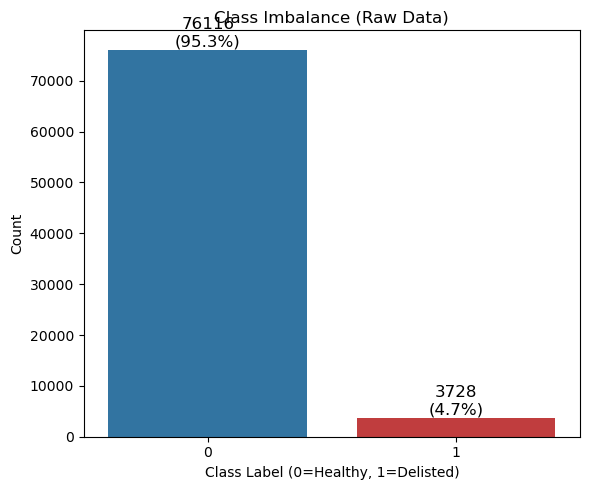

2. 製作敘述統計表 (Raw Data)...
-> 統計表已儲存 (請看 Skewness 欄位，數值應該很大)


,count,mean,std,min,50%,max,skewness,kurtosis
act,40613.0,2009.53,9346.14,0.00,138.58,264889.39,12.17,202.25
at,54110.0,24980.98,174056.83,0.00,799.87,4349731.00,13.92,234.30
che,47968.0,2323.78,26041.07,-0.01,57.96,1058786.12,23.02,630.73
dlc,53568.0,1561.54,16732.51,0.00,8.00,614237.41,19.72,463.65
dltt,54002.0,4781.37,75563.64,0.00,60.48,4216909.00,46.49,2319.00


3. 繪製 Box Plot (Raw Data)...


C:\Users\User-NB\AppData\Local\Temp\ipykernel_31804\2740164676.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Feature', y='Z-Score', data=df_melt, palette="viridis")


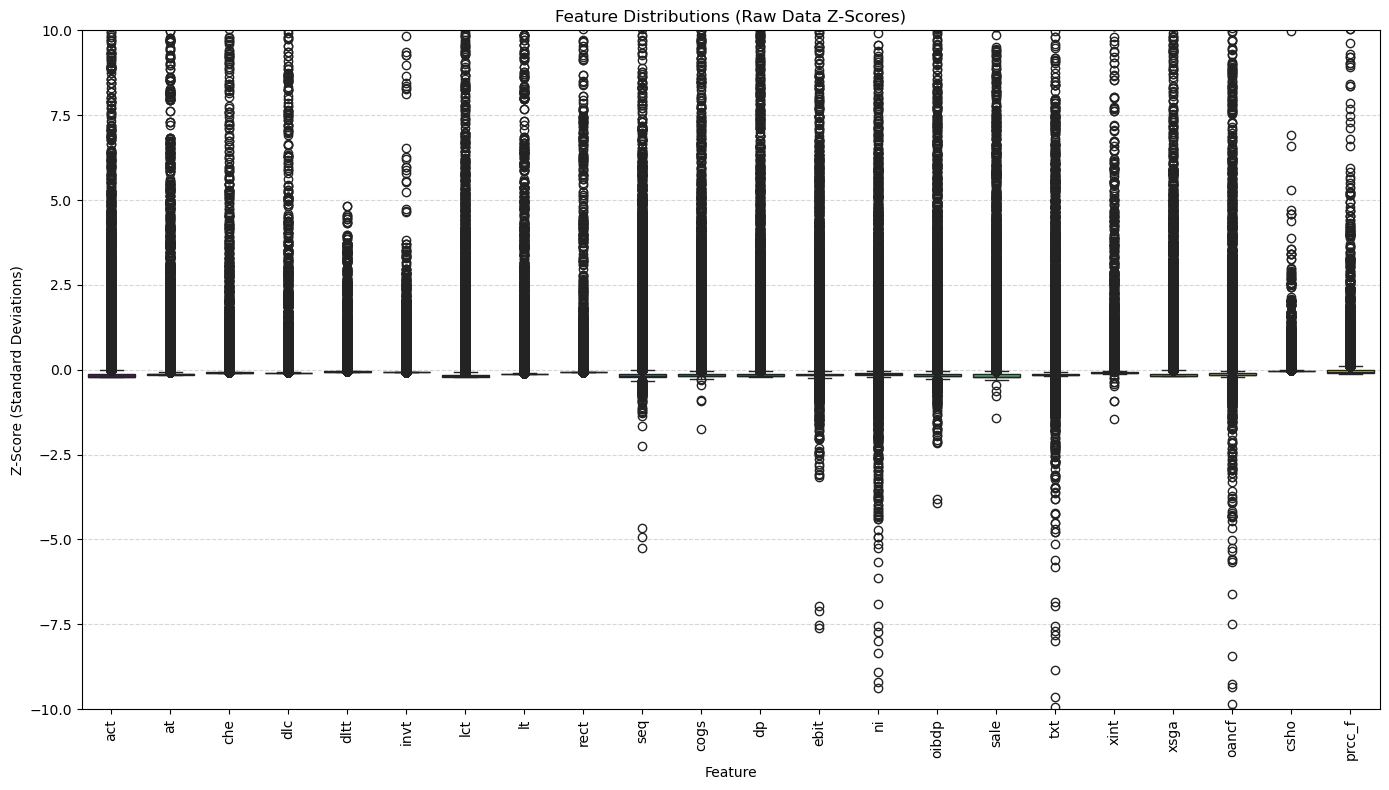

Boxplot 說明: Y軸限制在 +/-10 標準差，可以看到很多點點(極端值)超出範圍，證明需要 Winsorization
4. 繪製 Correlation Heatmap (Raw Data)...


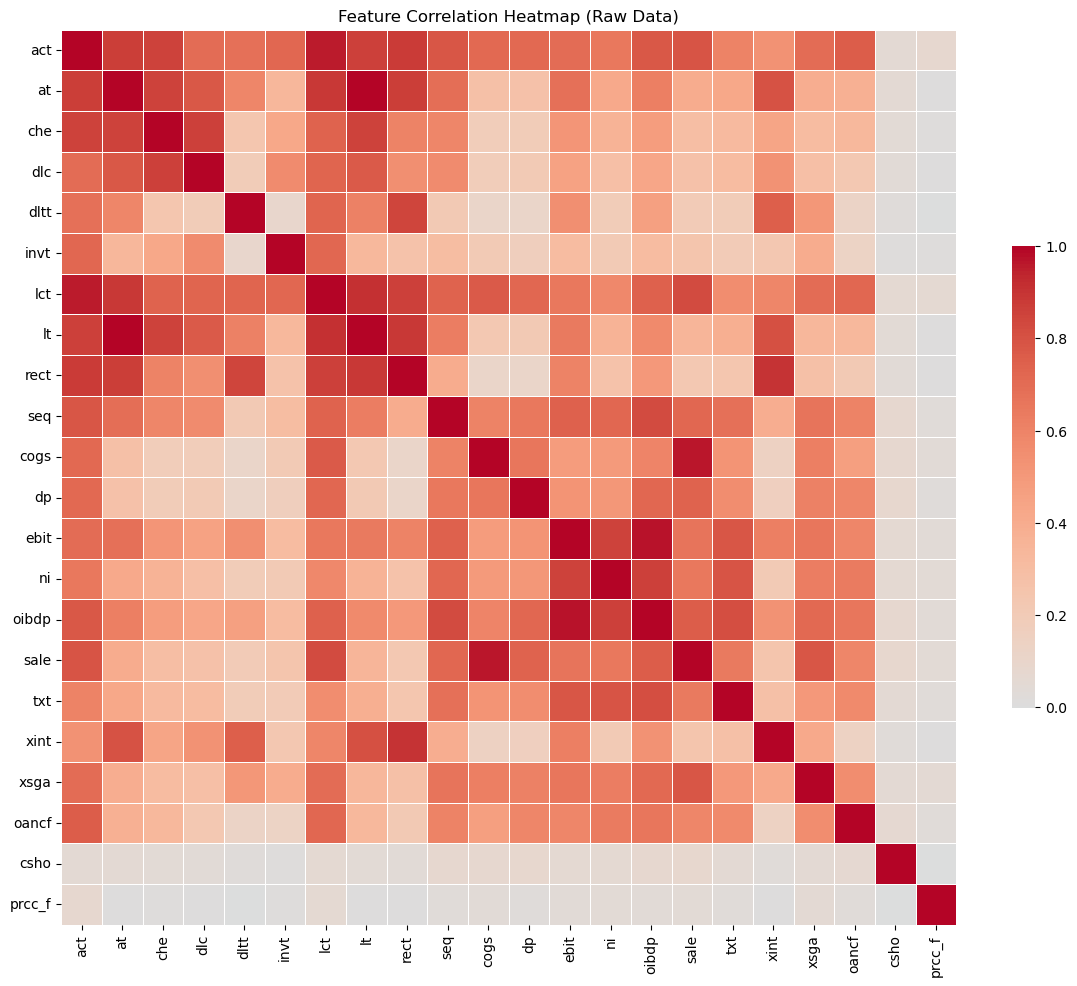

5. 繪製 ROC Curve (Benchmark vs Best Model)...
   - Retraining Best Model (No SMOTE + Ridge λ=100)...


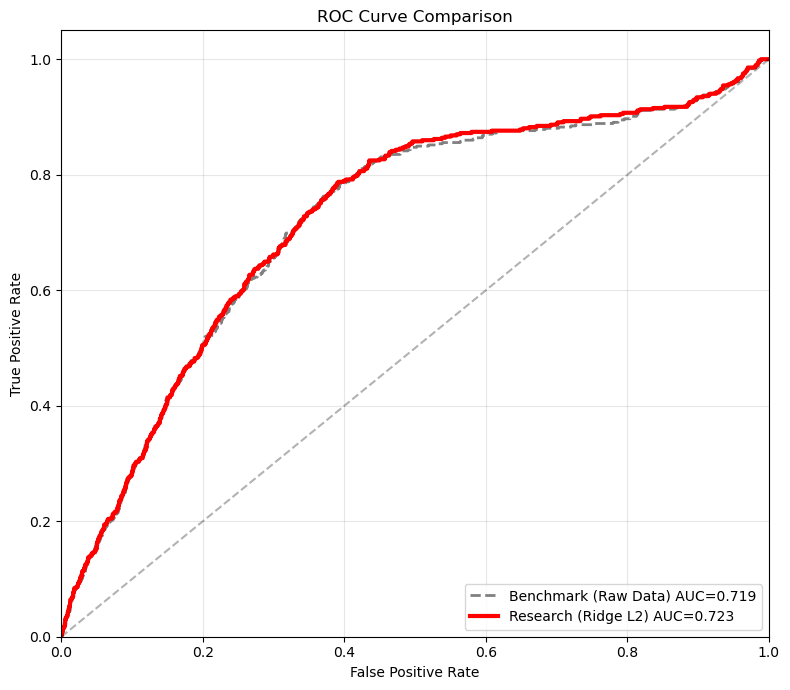


✅ 修正完成！原始資料 EDA 與模型結果 ROC 已儲存至 C:\Users\User-NB\OneDrive\Desktop\ML\ppt_images


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression

# --- 設定路徑 ---
BASE_DIR = r"C:\Users\User-NB\OneDrive\Desktop\ML"
# ★★★ 關鍵修正：EDA 讀取原始 CSV，而不是處理過的 PKL ★★★
RAW_CSV = os.path.join(BASE_DIR, "Fundamentals Annual_withY.csv")
RESULT_DIR = os.path.join(BASE_DIR, "results")
DATA_PATH = os.path.join(BASE_DIR, "processed_data", "data_processed.pkl") # 只有 ROC 需要用到處理後數據
IMG_DIR = os.path.join(BASE_DIR, "ppt_images")
os.makedirs(IMG_DIR, exist_ok=True)

print(f"圖表將儲存至: {IMG_DIR}")

# 1. 載入原始資料 (Raw Data)
print("載入原始 CSV 資料...")
df_raw = pd.read_csv(RAW_CSV)

# 定義要分析的財務變數 (排除 ID 類)
exclude_cols = ['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'gvkey', 'datadate', 'cik', 'sic', 'fyear', 'Y', 'tic', 'conm', 'SIC2']
feat_names = [c for c in df_raw.columns if c not in exclude_cols]
print(f"分析特徵: {len(feat_names)} 個")

# ==========================================
# 1. Class Imbalance Plot (類別不平衡)
# ==========================================
print("1. 繪製 Class Imbalance 圖 (Raw)...")
plt.figure(figsize=(6, 5))
# 直接統計 CSV 裡的 Y
ax = sns.countplot(x='Y', data=df_raw, palette=['#1f77b4', '#d62728']) 
plt.title("Class Imbalance (Raw Data)")
plt.xlabel("Class Label (0=Healthy, 1=Delisted)")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df_raw):.1%})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "eda_class_imbalance.png"))
plt.show()

# ==========================================
# 2. Descriptive Statistics Table (Skewness & Kurtosis)
# ==========================================
print("2. 製作敘述統計表 (Raw Data)...")
# 針對原始數據計算，這樣 Skewness 才會很大，證明需要 Log
desc = df_raw[feat_names].describe().T
desc['skewness'] = df_raw[feat_names].skew()
desc['kurtosis'] = df_raw[feat_names].kurt()

cols_order = ['count', 'mean', 'std', 'min', '50%', 'max', 'skewness', 'kurtosis']
final_table = desc[cols_order].round(2)

csv_path = os.path.join(IMG_DIR, "eda_descriptive_stats.csv")
final_table.to_csv(csv_path)
print(f"-> 統計表已儲存 (請看 Skewness 欄位，數值應該很大)")
display(final_table.head()) 

# ==========================================
# 3. Box Plot (原始分佈)
# ==========================================
print("3. 繪製 Box Plot (Raw Data)...")
plt.figure(figsize=(14, 8))

# 因為原始數據 scale 差異巨大 (例如 at 是十億級，ROA 是小數點)，直接畫會看不清楚
# 為了在 PPT 展示「極端值很多」，我們對數據做一個簡單的 log1p 處理來畫圖，
# 或者直接畫原始數據但限制 Y 軸，這裡選擇「畫出極端值」的感覺
df_plot = df_raw[feat_names].copy()

# 為了讓圖表可讀，我們把數據標準化一下 (只為了畫圖，不影響數據)
# 這樣可以看出相對的極端值
df_plot_scaled = (df_plot - df_plot.mean()) / df_plot.std()
df_melt = df_plot_scaled.melt(var_name='Feature', value_name='Z-Score')

sns.boxplot(x='Feature', y='Z-Score', data=df_melt, palette="viridis")
plt.title("Feature Distributions (Raw Data Z-Scores)")
plt.ylim(-10, 10) # 限制範圍，不然極端值會把圖撐到看不見盒子
plt.ylabel("Z-Score (Standard Deviations)")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(os.path.join(IMG_DIR, "eda_boxplot.png"))
plt.show()
print("Boxplot 說明: Y軸限制在 +/-10 標準差，可以看到很多點點(極端值)超出範圍，證明需要 Winsorization")

# ==========================================
# 4. Correlation Heatmap (原始相關性)
# ==========================================
print("4. 繪製 Correlation Heatmap (Raw Data)...")
plt.figure(figsize=(12, 10))
corr_matrix = df_raw[feat_names].corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title("Feature Correlation Heatmap (Raw Data)")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "eda_heatmap.png"))
plt.show()

# ==========================================
# 5. ROC Curve (這部分必須用模型結果)
# ==========================================
print("5. 繪製 ROC Curve (Benchmark vs Best Model)...")

# 載入 Benchmark 結果
bench_res = joblib.load(os.path.join(RESULT_DIR, "bench_results.pkl"))
fpr_bench, tpr_bench, _ = roc_curve(bench_res['y_test'], bench_res['y_prob'])
auc_bench = bench_res['auc'] if 'auc' in bench_res else bench_res['metrics']['AUC']

# 為了畫 Best Model，我們需要載入處理過的數據來重新預測一次
# (因為 Research 過程沒存所有模型的 prob)
data_processed = joblib.load(DATA_PATH)
X_res = data_processed["X_research"]
y_res = data_processed["y"]
fyear = data_processed["fyear"]

train_mask = (fyear >= 2019) & (fyear <= 2023)
test_mask = (fyear == 2024)
X_train, y_train = X_res[train_mask], y_res[train_mask]
X_test, y_test = X_res[test_mask], y_res[test_mask]

# 重跑最佳模型: No SMOTE + Ridge (lambda=100)
print("   - Retraining Best Model (No SMOTE + Ridge λ=100)...")
best_model = LogisticRegression(penalty='l2', C=0.01, solver='liblinear', random_state=42)
best_model.fit(X_train, y_train)
y_prob_best = best_model.predict_proba(X_test)[:, 1]
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(8, 7))
plt.plot(fpr_bench, tpr_bench, label=f'Benchmark (Raw Data) AUC={auc_bench:.3f}', 
         linestyle='--', color='gray', linewidth=2)
plt.plot(fpr_best, tpr_best, label=f'Research (Ridge L2) AUC={auc_best:.3f}', 
         color='red', linewidth=3)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "result_roc_curve.png"))
plt.show()

print(f"\n✅ 修正完成！原始資料 EDA 與模型結果 ROC 已儲存至 {IMG_DIR}")